# AI4I 2020 Predictive Maintenance Dataset

**Dataset:** `ai4i2020.csv` — 10,000 synthetic milling machine records  
**Target:** `Machine failure` (binary) with 5 failure sub-types: TWF, HDF, PWF, OSF, RNF

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

DATA_PATH = '../data/raw_data/ai4i2020.csv'
df = pd.read_csv(DATA_PATH)

# Clean column names
df.columns = df.columns.str.strip()

print(f'Shape: {df.shape}')
df.head()

Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 1. Dataset Overview

In [4]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Basic Statistics ===')
df.describe(include='all').T

=== Data Types ===
UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

=== Basic Statistics ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
UDI,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
Product ID,10000,10000,M14860,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,10000,3,L,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air temperature [K],10000.0,NaN,NaN,NaN,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,NaN,NaN,NaN,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,NaN,NaN,NaN,1538.7761,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,NaN,NaN,NaN,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,NaN,NaN,NaN,107.951,63.654147,0.0,53.0,108.0,162.0,253.0
Machine failure,10000.0,NaN,NaN,NaN,0.0339,0.180981,0.0,0.0,0.0,0.0,1.0
TWF,10000.0,NaN,NaN,NaN,0.0046,0.067671,0.0,0.0,0.0,0.0,1.0


In [5]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values found.')

print('\n=== Duplicate Rows ===')
print(f'{df.duplicated().sum()} duplicate rows')

=== Missing Values ===
No missing values found.

=== Duplicate Rows ===
0 duplicate rows


## 2. Target Variable — Machine Failure

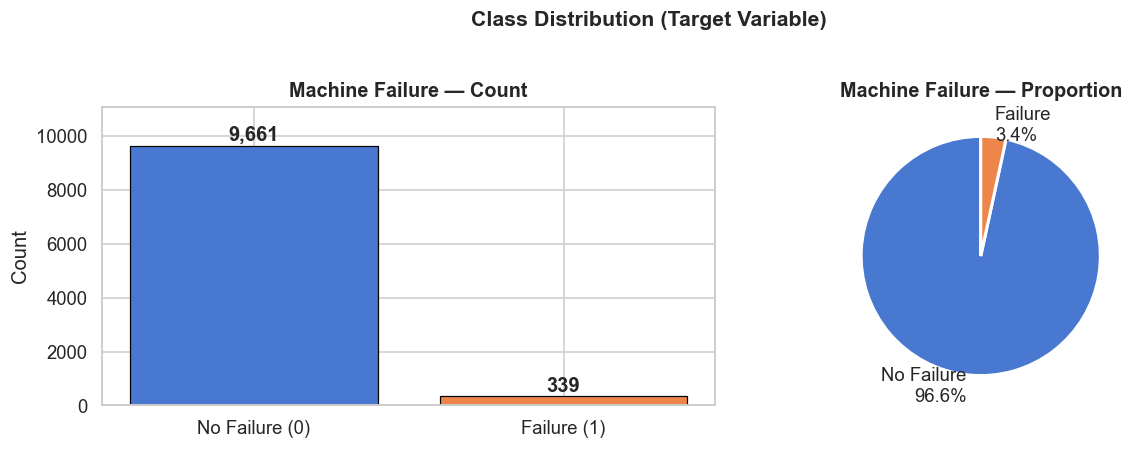

Class imbalance ratio — No Failure : Failure = 96.6% : 3.4%


In [6]:
failure_counts = df['Machine failure'].value_counts()
failure_pct = df['Machine failure'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count bar
bars = axes[0].bar(['No Failure (0)', 'Failure (1)'],
                   failure_counts.values,
                   color=sns.color_palette('muted')[:2], edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, failure_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Machine Failure — Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, failure_counts.max() * 1.15)

# Pie chart
axes[1].pie(failure_pct.values,
            labels=[f'No Failure\n{failure_pct[0]:.1f}%', f'Failure\n{failure_pct[1]:.1f}%'],
            colors=sns.color_palette('muted')[:2],
            startangle=90, autopct='', wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Machine Failure — Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Class Distribution (Target Variable)', fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Class imbalance ratio — No Failure : Failure = {failure_pct[0]:.1f}% : {failure_pct[1]:.1f}%')

## 3. Failure Sub-Type Analysis

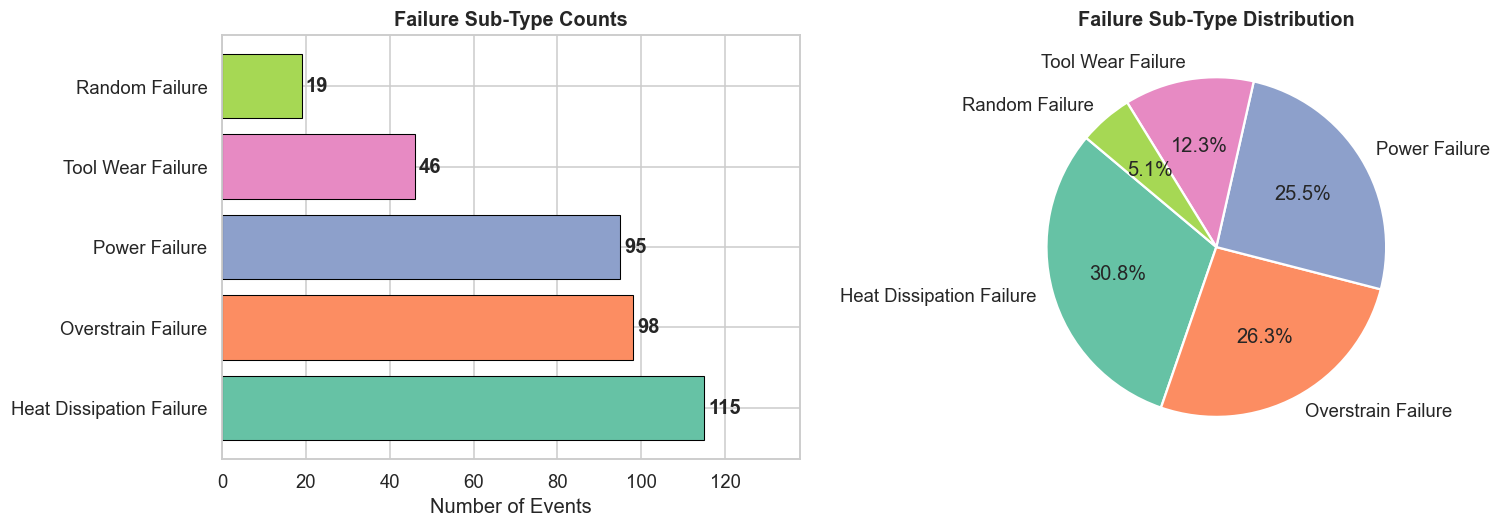

Total failure events: 339
Failures with multiple sub-types: 24


In [7]:
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_labels = {
    'TWF': 'Tool Wear Failure',
    'HDF': 'Heat Dissipation Failure',
    'PWF': 'Power Failure',
    'OSF': 'Overstrain Failure',
    'RNF': 'Random Failure'
}

ft_counts = df[failure_types].sum().sort_values(ascending=False)
ft_pct = (ft_counts / len(df)) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
palette = sns.color_palette('Set2', len(failure_types))
bars = axes[0].barh([failure_labels[f] for f in ft_counts.index],
                    ft_counts.values,
                    color=palette, edgecolor='black', linewidth=0.7)
for bar, val in zip(bars, ft_counts.values):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{val}', va='center', fontweight='bold')
axes[0].set_title('Failure Sub-Type Counts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Events')
axes[0].set_xlim(0, ft_counts.max() * 1.2)

# Pie chart of sub-types
axes[1].pie(ft_counts.values,
            labels=[failure_labels[f] for f in ft_counts.index],
            colors=palette, autopct='%1.1f%%',
            startangle=140, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Failure Sub-Type Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Check overlap
df_fail = df[df['Machine failure'] == 1]
print(f'Total failure events: {len(df_fail)}')
print(f'Failures with multiple sub-types: {(df_fail[failure_types].sum(axis=1) > 1).sum()}')

## 4. Machine Type Distribution

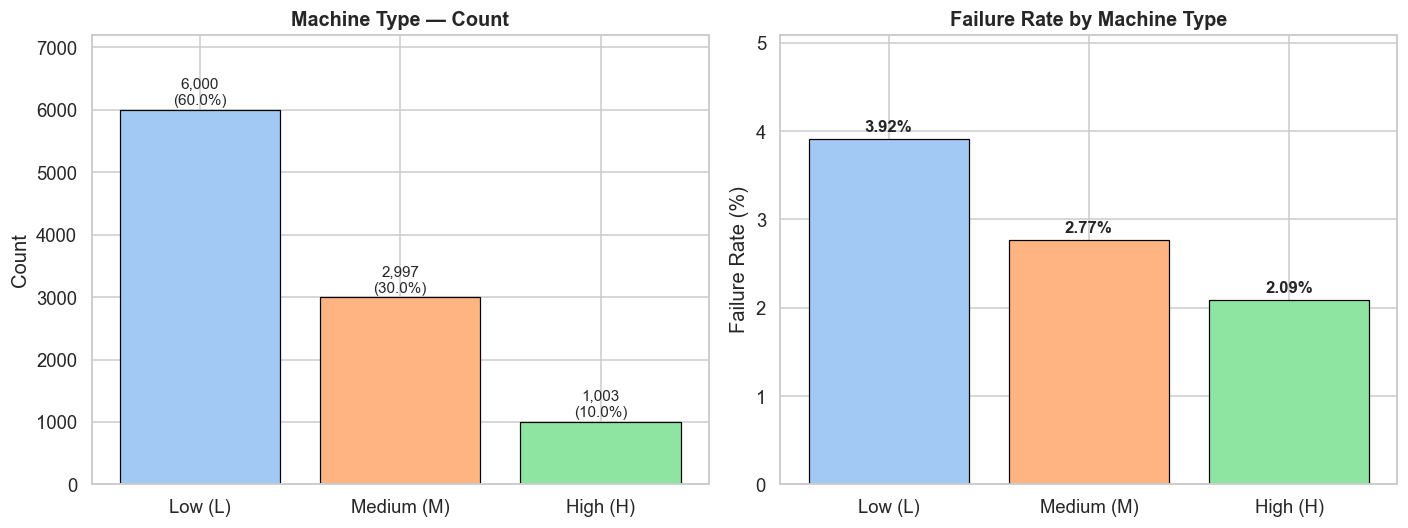

In [8]:
type_labels = {'L': 'Low (L)', 'M': 'Medium (M)', 'H': 'High (H)'}
type_counts = df['Type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Count by type
palette_type = sns.color_palette('pastel')[:3]
bars = axes[0].bar([type_labels[t] for t in type_counts.index],
                   type_counts.values,
                   color=palette_type, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, type_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Machine Type — Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, type_counts.max() * 1.2)

# Failure rate by type
fail_rate = df.groupby('Type')['Machine failure'].mean() * 100
fail_rate = fail_rate.reindex(['L', 'M', 'H'])
bars2 = axes[1].bar([type_labels[t] for t in fail_rate.index],
                    fail_rate.values,
                    color=palette_type, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars2, fail_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('Failure Rate by Machine Type', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Failure Rate (%)')
axes[1].set_ylim(0, fail_rate.max() * 1.3)

plt.tight_layout()
plt.show()

## 5. Numerical Feature Distributions

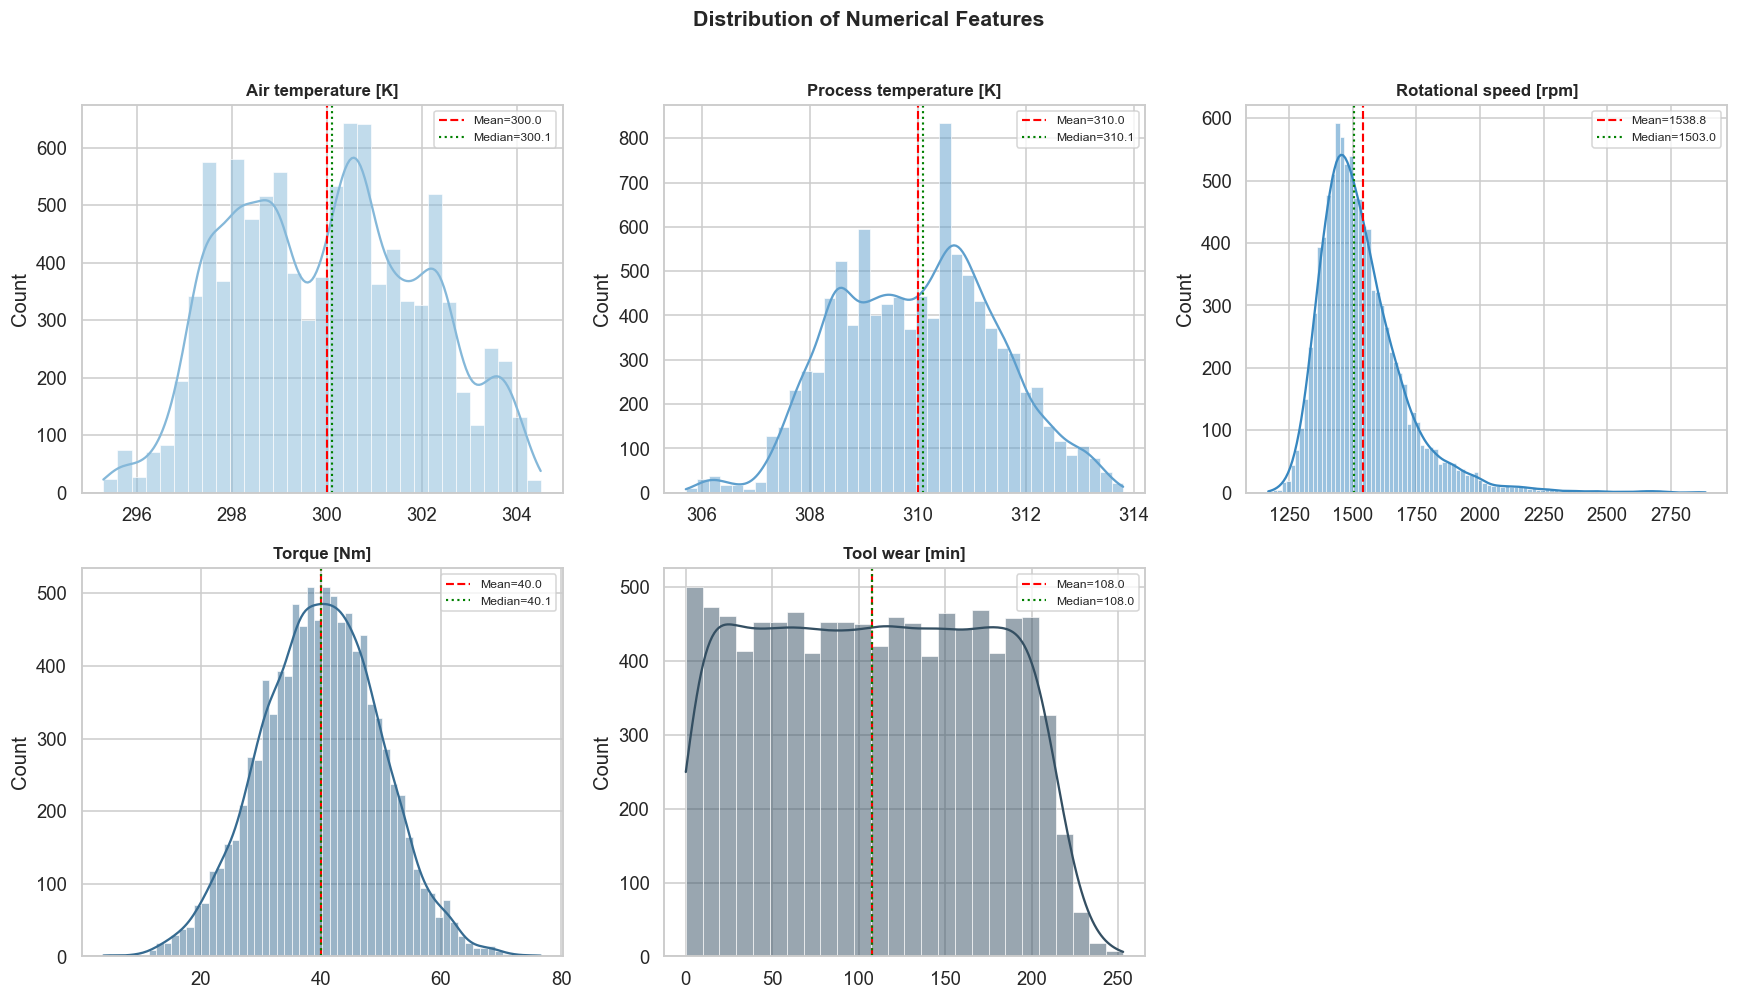

In [9]:
num_features = ['Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

colors = sns.color_palette('Blues_d', len(num_features))

for i, col in enumerate(num_features):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color=colors[i], edgecolor='white', linewidth=0.4)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    mean_val = df[col].mean()
    median_val = df[col].median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.4, label=f'Mean={mean_val:.1f}')
    ax.axvline(median_val, color='green', linestyle=':', linewidth=1.4, label=f'Median={median_val:.1f}')
    ax.legend(fontsize=8)

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle('Distribution of Numerical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Box Plots — Features by Failure Status

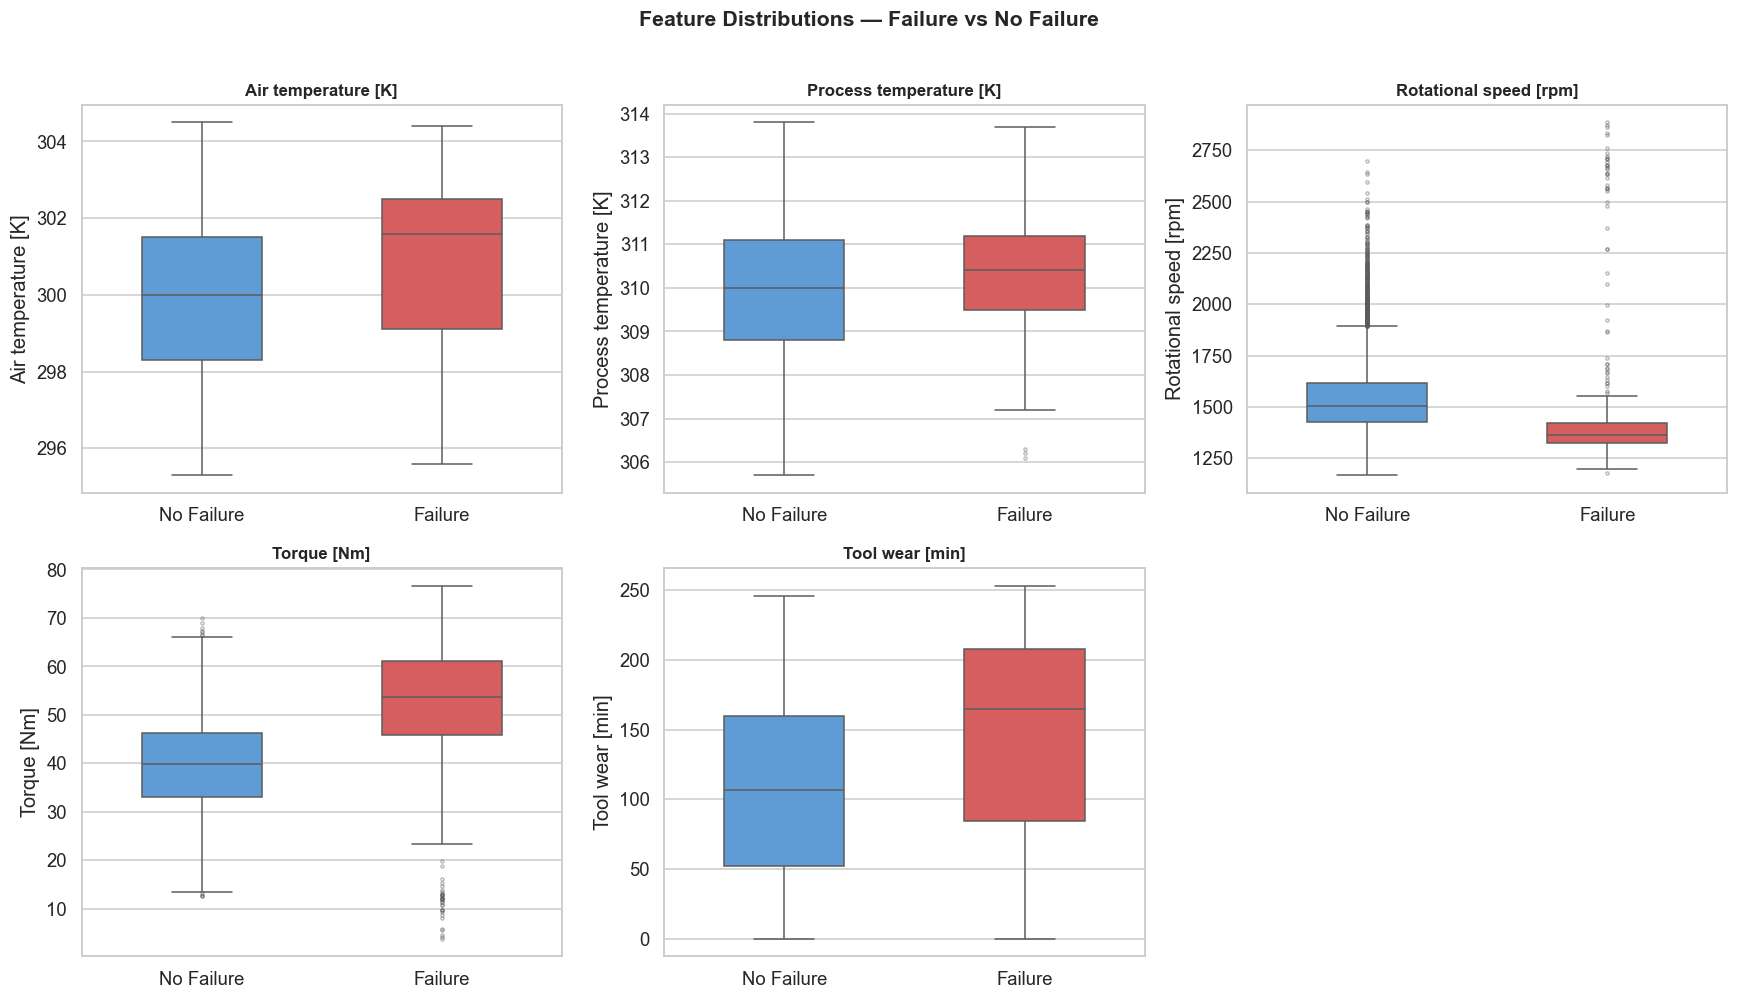

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

palette_fail = {'0': '#4C9BE8', '1': '#E84C4C'}

for i, col in enumerate(num_features):
    ax = axes[i]
    sns.boxplot(data=df, x='Machine failure', y=col, ax=ax,
                palette=palette_fail, width=0.5,
                flierprops=dict(marker='o', markersize=2, alpha=0.4))
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xticklabels(['No Failure', 'Failure'])
    ax.set_xlabel('')

axes[-1].set_visible(False)

plt.suptitle('Feature Distributions — Failure vs No Failure', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Violin Plots — Features by Machine Type & Failure

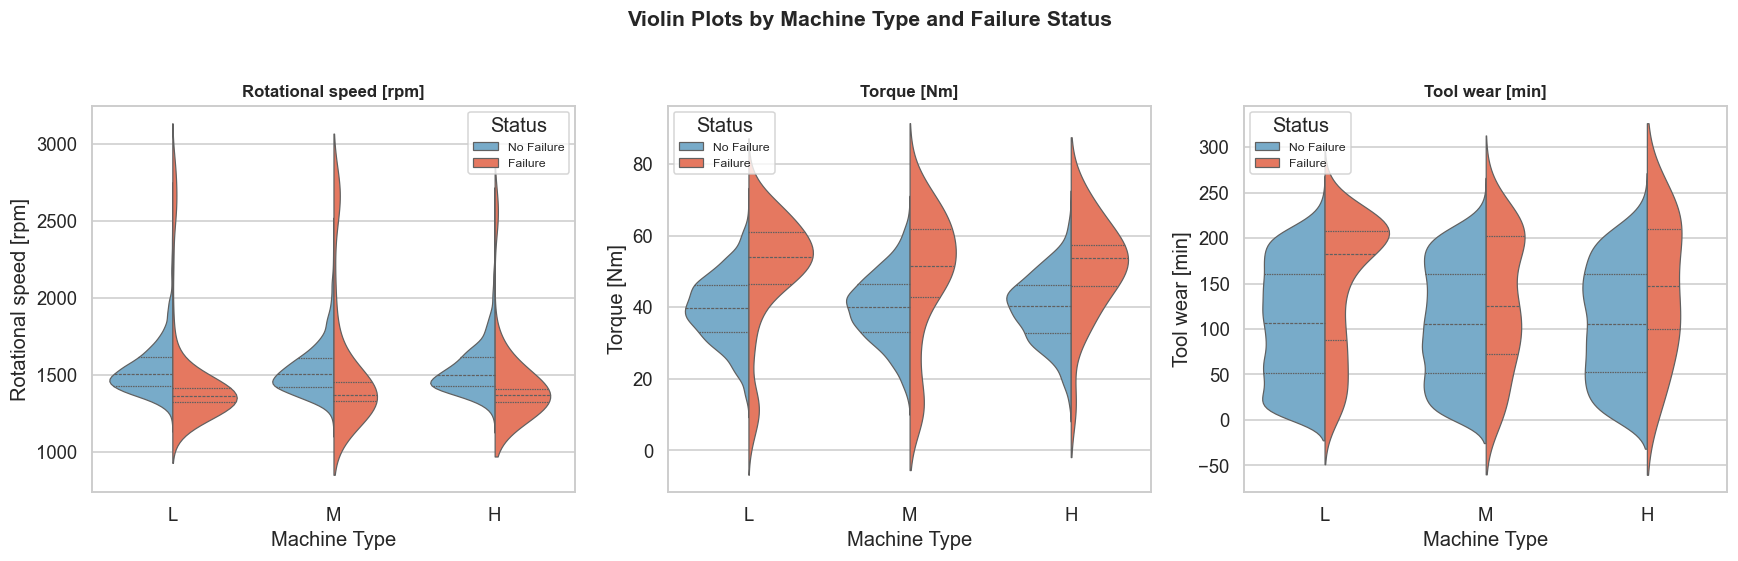

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

key_features = ['Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

for ax, col in zip(axes, key_features):
    sns.violinplot(data=df, x='Type', y=col, hue='Machine failure',
                   split=True, ax=ax, palette=['#6BAED6', '#FB6A4A'],
                   order=['L', 'M', 'H'], inner='quartile', linewidth=0.8)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('Machine Type')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ['No Failure', 'Failure'], title='Status', fontsize=8)

plt.suptitle('Violin Plots by Machine Type and Failure Status', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Correlation Heatmap

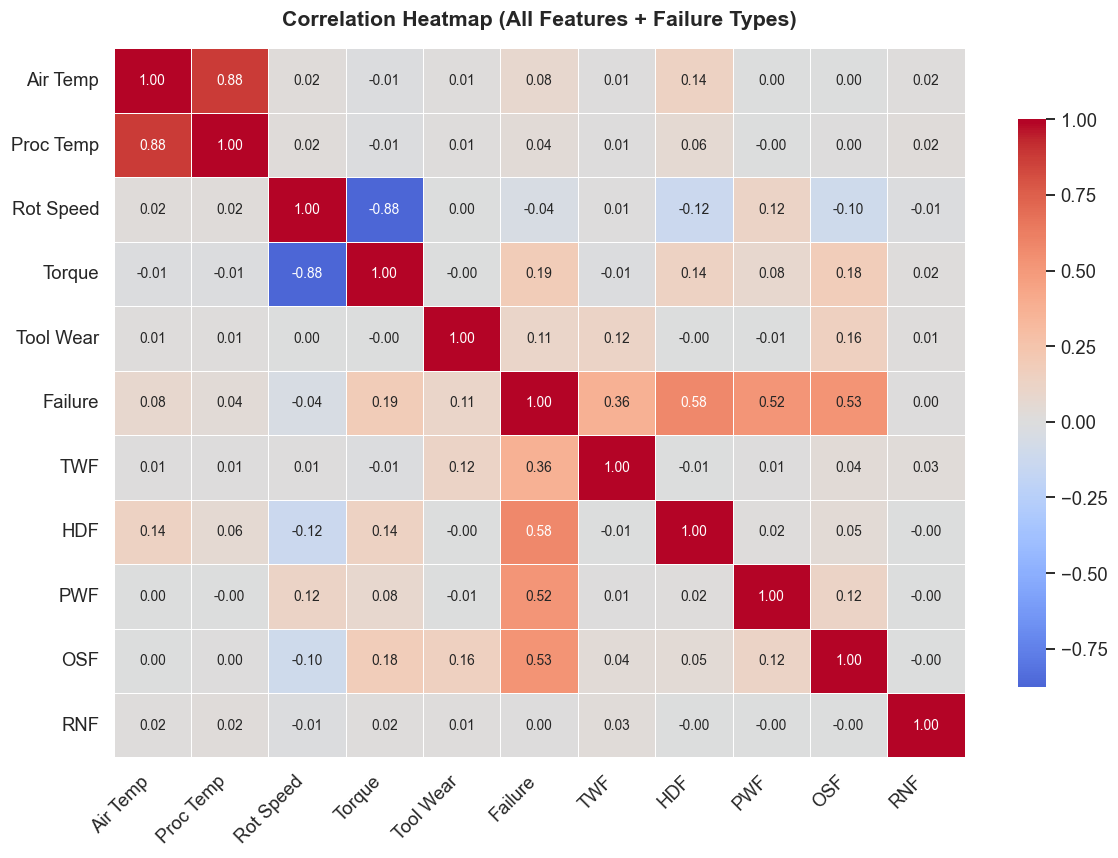

In [15]:
corr_cols = num_features + ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
corr_matrix = df[corr_cols].corr()

# Shorten labels
short_labels = {
    'Air temperature [K]': 'Air Temp',
    'Process temperature [K]': 'Proc Temp',
    'Rotational speed [rpm]': 'Rot Speed',
    'Torque [Nm]': 'Torque',
    'Tool wear [min]': 'Tool Wear',
    'Machine failure': 'Failure'
}
corr_matrix.rename(index=short_labels, columns=short_labels, inplace=True)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, linecolor='white',
            ax=ax, cbar_kws={'shrink': 0.8}, annot_kws={'size': 9})
ax.set_title('Correlation Heatmap (All Features + Failure Types)',
             fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Scatter Plots — Key Feature Interactions

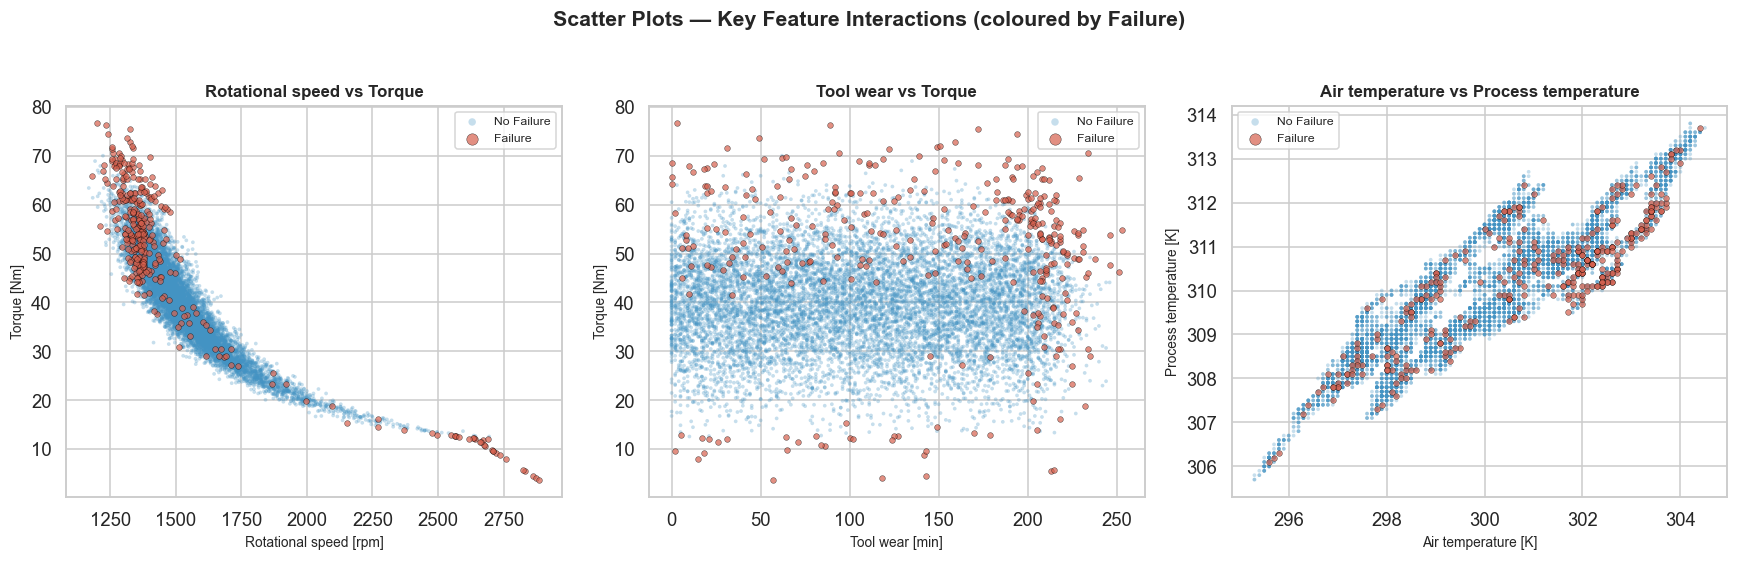

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

scatter_pairs = [
    ('Rotational speed [rpm]', 'Torque [Nm]'),
    ('Tool wear [min]', 'Torque [Nm]'),
    ('Air temperature [K]', 'Process temperature [K]'),
]

colors_map = {0: '#4393C3', 1: '#D6604D'}

for ax, (x_col, y_col) in zip(axes, scatter_pairs):
    for label, grp in df.groupby('Machine failure'):
        ax.scatter(grp[x_col], grp[y_col],
                   c=colors_map[label],
                   label='Failure' if label == 1 else 'No Failure',
                   alpha=0.3 if label == 0 else 0.7,
                   s=6 if label == 0 else 14,
                   edgecolors='none' if label == 0 else 'black',
                   linewidths=0.3)
    ax.set_xlabel(x_col, fontsize=9)
    ax.set_ylabel(y_col, fontsize=9)
    ax.set_title(f'{x_col.split("[")[0].strip()} vs {y_col.split("[")[0].strip()}',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, markerscale=2)

plt.suptitle('Scatter Plots — Key Feature Interactions (coloured by Failure)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Power & Heat Dissipation — Derived Features

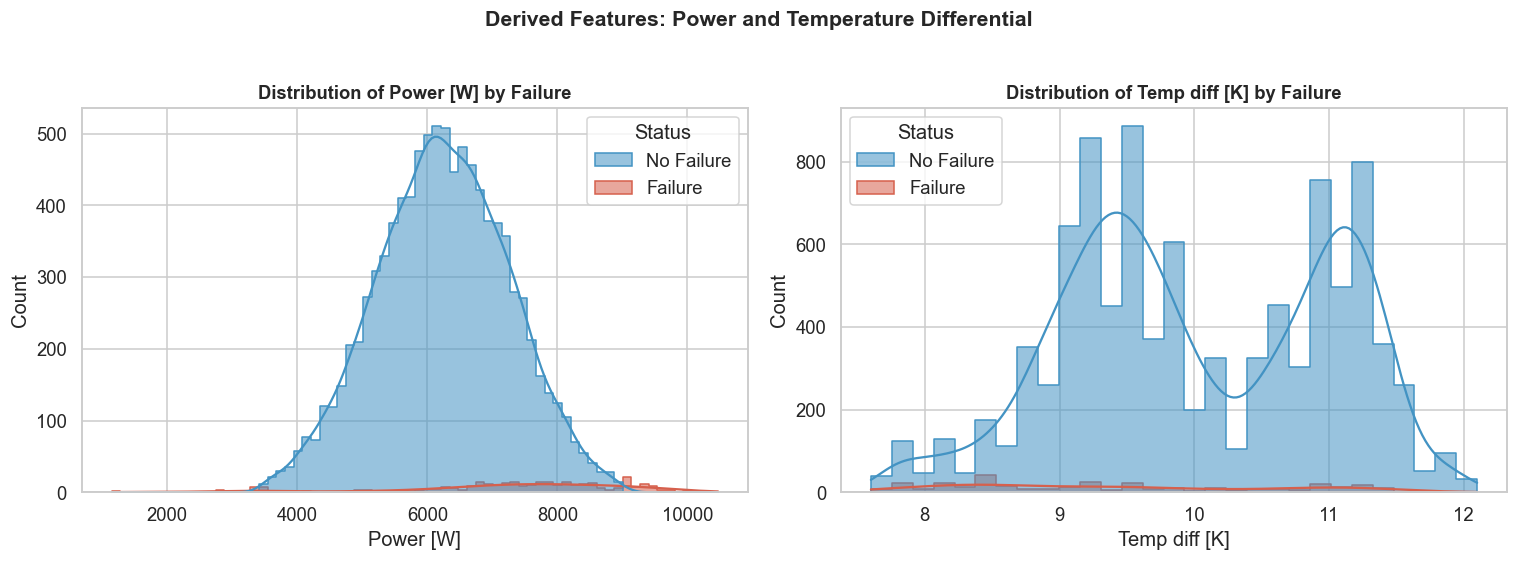

In [18]:
# Derived features used internally in AI4I dataset generation
df['Power [W]'] = df['Torque [Nm]'] * df['Rotational speed [rpm]'] * (2 * np.pi / 60)
df['Temp diff [K]'] = df['Process temperature [K]'] - df['Air temperature [K]']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['Power [W]', 'Temp diff [K]']):
    sns.histplot(data=df, x=col, hue='Machine failure', ax=ax,
                 kde=True, palette={'#4393C3','#D6604D'},
                 alpha=0.55, element='step', common_norm=False)
    ax.set_title(f'Distribution of {col} by Failure', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    handles = ax.get_legend().legend_handles
    ax.legend(handles, ['No Failure', 'Failure'], title='Status')

plt.suptitle('Derived Features: Power and Temperature Differential', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 11. Failure Type Heatmap — Co-occurrence

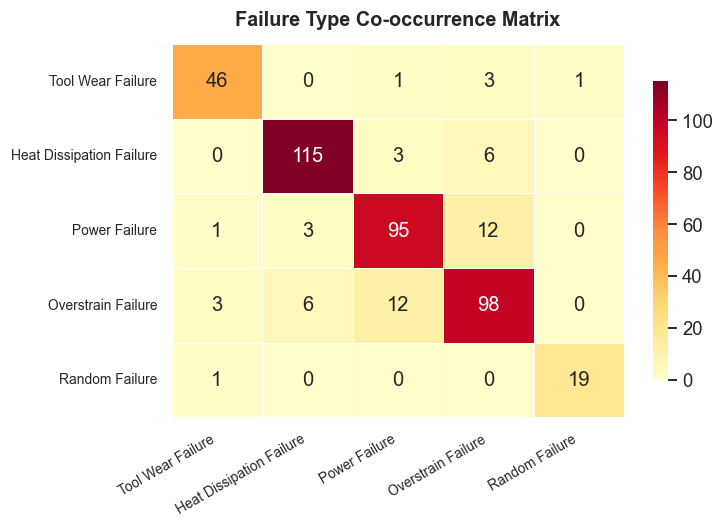

In [19]:
co_matrix = df[failure_types].T.dot(df[failure_types])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(co_matrix, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'shrink': 0.8},
            xticklabels=[failure_labels[f] for f in failure_types],
            yticklabels=[failure_labels[f] for f in failure_types])
ax.set_title('Failure Type Co-occurrence Matrix', fontsize=13, fontweight='bold', pad=12)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

## 12. Pairplot — Core Features Coloured by Failure

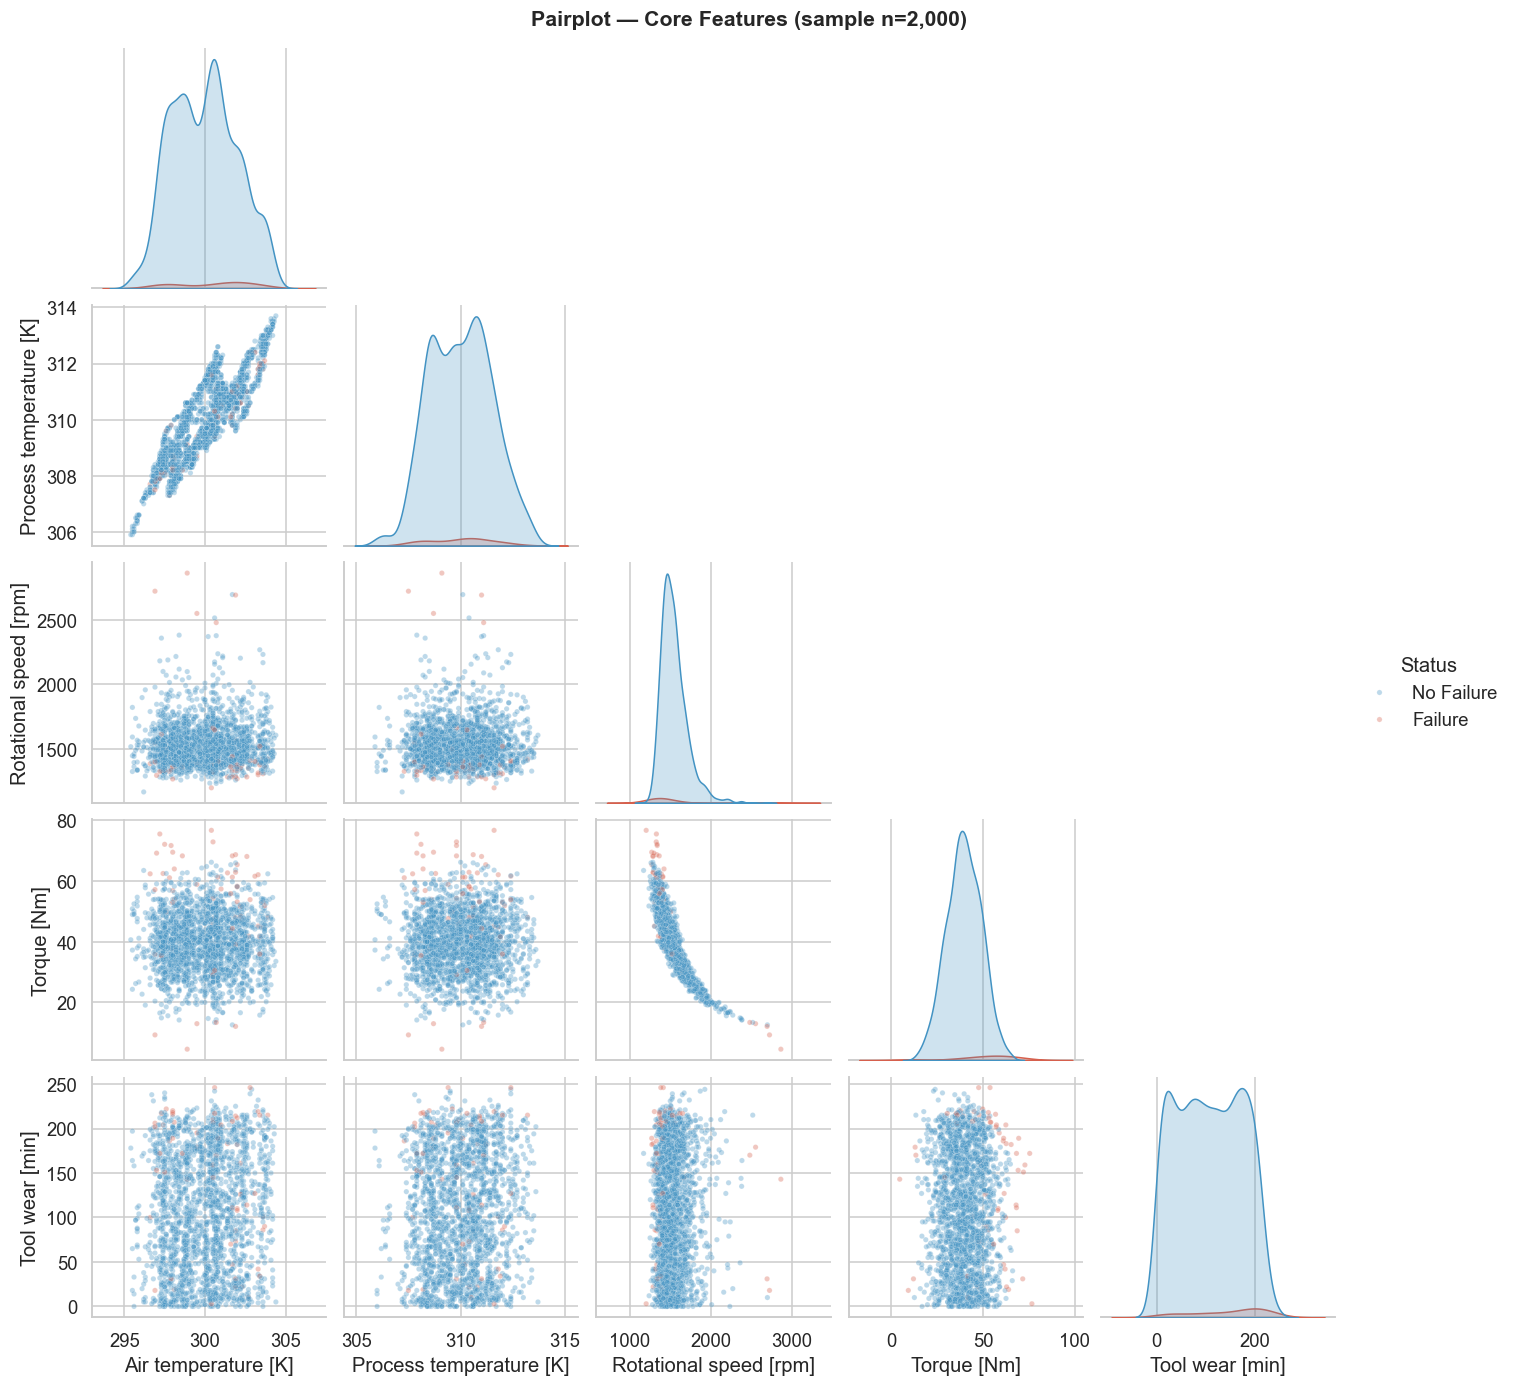

In [21]:
pair_cols = ['Air temperature [K]', 'Process temperature [K]',
             'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']

pair_df = df[pair_cols].copy()
pair_df['Machine failure'] = pair_df['Machine failure'].map({0: 'No Failure', 1: 'Failure'})

# Subsample to keep rendering fast
sample = pair_df.sample(n=2000, random_state=42)

g = sns.pairplot(sample, hue='Machine failure',
                 palette={'No Failure': '#4393C3', 'Failure': '#D6604D'},
                 plot_kws={'alpha': 0.35, 's': 12},
                 diag_kind='kde',
                 corner=True)
g.figure.suptitle('Pairplot — Core Features (sample n=2,000)', y=1.01, fontsize=14, fontweight='bold')
g._legend.set_title('Status')
plt.show()

## 13. Tool Wear Over Time — Cumulative View

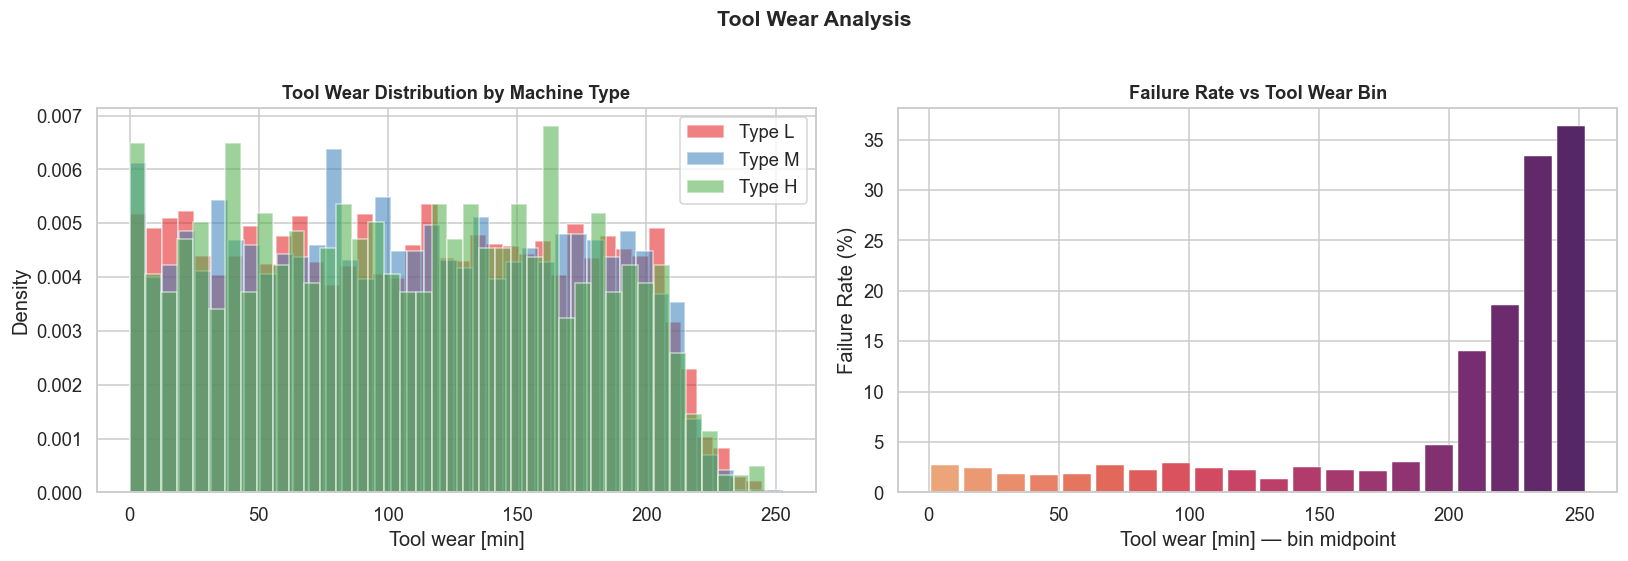

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Tool wear distribution by machine type
for t, color in zip(['L', 'M', 'H'], sns.color_palette('Set1', 3)):
    subset = df[df['Type'] == t]['Tool wear [min]']
    axes[0].hist(subset, bins=40, alpha=0.55, label=f'Type {t}', color=color, density=True)
axes[0].set_title('Tool Wear Distribution by Machine Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tool wear [min]')
axes[0].set_ylabel('Density')
axes[0].legend()

# Tool wear vs failure
bins = pd.cut(df['Tool wear [min]'], bins=20)
fail_by_wear = df.groupby(bins, observed=True)['Machine failure'].mean() * 100
midpoints = [interval.mid for interval in fail_by_wear.index]
axes[1].bar(midpoints, fail_by_wear.values,
            width=(df['Tool wear [min]'].max() / 20) * 0.85,
            color=sns.color_palette('flare', 20), edgecolor='white', linewidth=0.3)
axes[1].set_title('Failure Rate vs Tool Wear Bin', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tool wear [min] — bin midpoint')
axes[1].set_ylabel('Failure Rate (%)')

plt.suptitle('Tool Wear Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()